##Data Preprocessing

In [136]:
import pandas as pd

In [137]:
bang = pd.read_csv("/content/Bangalore.csv")
chen = pd.read_csv("/content/Chennai.csv")
delh = pd.read_csv("/content/Delhi.csv")
hydr = pd.read_csv("/content/Hyderabad.csv")
kolk = pd.read_csv("/content/Kolkata.csv")
mumb = pd.read_csv("/content/Mumbai.csv")

In [138]:
margeData = pd.concat([bang,chen,delh,hydr,kolk,mumb]) #All Csv fille in one(Marge).

margeData

,Price,Area,Location,No. of Bedrooms,Resale,MaintenanceStaff,Gymnasium,SwimmingPool,LandscapedGardens,JoggingTrack,...,LiftAvailable,BED,VaastuCompliant,Microwave,GolfCourse,TV,DiningTable,Sofa,Wardrobe,Stadium
0,30000000,3340,JP Nagar Phase 1,4,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
1,7888000,1045,Dasarahalli on Tumkur Road,2,0,0,1,1,1,1,...,1,0,1,0,0,0,0,0,0,0
2,4866000,1179,Kannur on Thanisandra Main Road,2,0,0,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
3,8358000,1675,Doddanekundi,3,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,6845000,1670,Kengeri,3,0,1,1,1,1,1,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7714,14500000,1180,Mira Road East,2,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
7715,14500000,530,Naigaon East,1,1,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
7716,4100000,700,Shirgaon,1,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9
7717,2750000,995,Mira Road East,2,0,9,9,9,9,9,...,9,9,9,9,9,9,9,9,9,9


In [139]:
margeData.isnull().sum() #Check null value with doing Sum and do count

,0
Price,0
Area,0
Location,0
No. of Bedrooms,0
Resale,0
MaintenanceStaff,0
Gymnasium,0
SwimmingPool,0
LandscapedGardens,0
JoggingTrack,0


In [140]:
margeData.to_csv("margeData.csv", index = False)

##Model Implementation

In [141]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from xgboost import XGBRFRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression

In [142]:
import matplotlib.pyplot as plt

In [143]:
data = pd.read_csv("/content/margeData.csv")

In [144]:
x = data.drop(columns=[data.columns[-1]]).values #rest of ther data
y = data.iloc[:, -1].values #Price data

##Lable Encoding

In [145]:
lable_encoder = LabelEncoder()
x[:, data.columns.get_loc("Location")] = lable_encoder.fit_transform(data["Location"])

##Train Test Split

In [146]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

##Linner Regrassion

In [147]:
lin_reg = LinearRegression()

In [148]:
lin_reg.fit(X_train, y_train)

LinearRegression()

In [149]:
y_pred_lin = lin_reg.predict(X_test)

In [150]:
accuracy_lin = lin_reg.score(X_test, y_test)

In [151]:
print(f'Linner Regrassion: {accuracy_lin * 100}')

Linner Regrassion: 99.98661826314584


##Logistic Regression

In [152]:
log_reg = LogisticRegression()

In [153]:
log_reg.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [154]:
y_pred_log = log_reg.predict(X_test)

In [155]:
accuracy_log = log_reg.score(X_test, y_test)

In [156]:
print(f'Logistic Regression Accuracy: {accuracy_log * 100}')

Logistic Regression Accuracy: 69.57379038374033


##XGBOOST

In [157]:
xgb_reg = XGBRFRegressor()

In [158]:
xgb_reg.fit(X_train, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, reg_alpha=None, ...)

In [159]:
y_pred_xgb = xgb_reg.predict(X_test)

In [160]:
accuracy_xgb = xgb_reg.score(X_test, y_test)

In [161]:
print(f'XGBOOST Accuracy: {accuracy_xgb * 100}')

XGBOOST Accuracy: 99.99164938926697


##Random Forest

In [162]:
rand_reg = RandomForestRegressor()

In [163]:
rand_reg.fit(X_train, y_train)

RandomForestRegressor()

In [164]:
y_pred_rand = rand_reg.predict(X_test)

In [165]:
accuracy_rand = rand_reg.score(X_test, y_test)

In [166]:
print(f'Random Forest Accuracy: {accuracy_rand * 100}')

Random Forest Accuracy: 99.99242100252317


## Model Accuracy Comparison

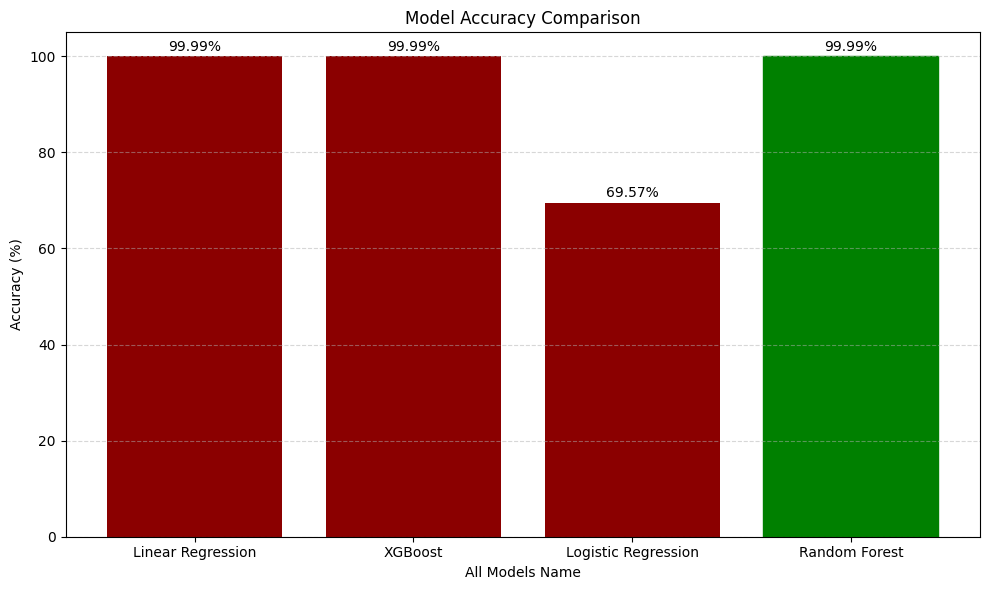

In [190]:
model_names = ['Linear Regression', 'XGBoost', 'Logistic Regression', 'Random Forest']   # Model names and their accuracies
accuracy_scores = [accuracy_lin, accuracy_xgb, accuracy_log, accuracy_rand]


best_index = accuracy_scores.index(max(accuracy_scores))  # Find the best-performing model

plt.figure(figsize=(10, 6)) # Plot
bars = plt.bar(model_names, [acc * 100 for acc in accuracy_scores], color='darkred')
bars[best_index].set_color('green')  # Highlight best model

for bar, score in zip(bars, accuracy_scores):  # Add accuracy values on top of the bars
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f'{score * 100:.2f}%', ha='center', va='bottom')



plt.title('Model Accuracy Comparison')
plt.xlabel('All Models Name')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 105)
plt.grid(axis='y', linestyle='--', alpha=0.50)
plt.tight_layout()
plt.show()